# Motion-Corrected Image Reconstruction (MCIR)


In [1]:
__version__ = '0.2.0'

# import engine module
import sirf.Gadgetron as pMR
from sirf.Utilities import examples_data_path
# from sirf_exercises import exercises_data_pathtoken
import sirf.Reg as pReg


from cil.framework import  AcquisitionGeometry, BlockDataContainer, BlockGeometry
from cil.optimisation.functions import Function, OperatorCompositionFunction, SmoothMixedL21Norm, L1Norm, L2NormSquared, BlockFunction, MixedL21Norm, IndicatorBox, TotalVariation, LeastSquares, ZeroFunction
from cil.optimisation.operators import GradientOperator, BlockOperator, ZeroOperator, CompositionOperator,LinearOperator
from cil.optimisation.algorithms import PDHG, FISTA, GD, SPDHG
from cil.plugins.ccpi_regularisation.functions import FGP_TV

# import further modules
import os
import numpy as np
import scipy.signal as sp_signal

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

import functools

import cil
import sirf

assert cil.version.version == '23.1.0'
assert sirf.__version__ == '3.5.0'

In [2]:
# Plotting function
data_path = '/home/jovyan/devel/SIRF-Contribs/src/notebooks/'
os.chdir(data_path)
import utils
from utils import plot_rpe_3d, plot_rpe_3d_simple
print ("Ciao")


Ciao


In [3]:
import importlib
importlib.reload(utils)
from utils import plot_rpe_3d, plot_rpe_3d_simple, saveCallback

In [4]:
############# SETUP #################
# number of motion states
Nms = 6
# max
max_shift = 20.
# setup linear shifts
shifts = np.linspace(0, 1, Nms) * max_shift

## Recon parameters
n_epochs = 100
# factor in front of L2Norm
omega = 0.5
# regularisation parameter
alpha = 2e-5

# data save directory
recons = 'recons_ignore-acq'


In [5]:
# data_path = exercises_data_path('MR')

filename = os.path.join(data_path, '3D_GRPE_no_motion.h5')

In [6]:
# Load in the data
acq_data = pMR.AcquisitionData(filename)
acq_data.sort_by_time()

reading from /home/jovyan/devel/SIRF-Contribs/src/notebooks/3D_GRPE_no_motion.h5 using ignore mask 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 0000 

Started reading acquisitions from /home/jovyan/devel/SIRF-Contribs/src/notebooks/3D_GRPE_no_motion.h5
0%..10%..20%..31%..40%..50%..61%..70%..80%..90%..
Finished reading acquisitions from /home/jovyan/devel/SIRF-Contribs/src/notebooks/3D_GRPE_no_motion.h5


In [7]:
csm = pMR.CoilSensitivityData()
csm.smoothness = 100
csm.calculate(acq_data) 

E = pMR.AcquisitionModel(acqs=acq_data, imgs=csm)
E.set_coil_sensitivity_maps(csm)


/tmp/ipykernel_18146/199382526.py:2: ComplexWarning: Casting complex values to real discards the imaginary part
  show2D(csm.abs().as_array().astype('float32'))


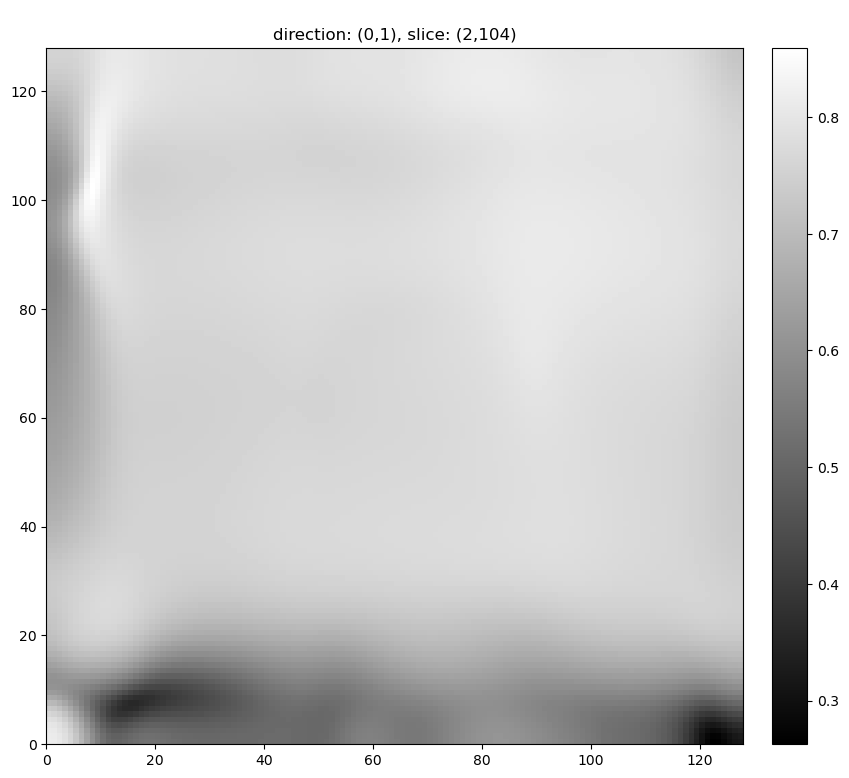

In [8]:
from cil.utilities.display import show2D
show2D(csm.abs().as_array().astype('float32'))

# Adding horizontal phase shift

In [9]:
# Get the information about the index of the phase encoding
pe_ky = acq_data.get_ISMRMRD_info('kspace_encode_step_1')

# Find the central value of each GRPE line (i.e. ky=0)
ky_idx = np.where(pe_ky == (np.max(pe_ky)+1)//2)

# Get the k-space as array
acq_data_arr = acq_data.as_array()

# Keep only points which have been acquired in the k-space centre (i.e. ky == 0 & kz == 0)
acq_data_arr = acq_data_arr[ky_idx[0], :, :]

# Select the last coil and the centre of each readout (i.e kx = 0) to get our final 1D motion signal
self_nav = np.abs(np.squeeze(acq_data_arr[:,3,acq_data_arr.shape[2]//2]))

# We said above that the value of the k-space centre should only vary because of motion. 
# This is not entirely true, because it can also vary because of other effects. One is that the spin system
# is in a transient steady state at the beginning of the data acquisition. 
# Therefore, we will simply overwrite the first entry in our motion signal
self_nav[0] = self_nav[1]

# Do some filtering
self_nav = sp_signal.medfilt(self_nav, 7)

# Interpolate self navigator to all phase encoding points
self_nav = np.interp(np.linspace(0, len(pe_ky)-1, len(pe_ky)), ky_idx[0], self_nav)

# Sort navigator and obtain index
nav_idx = np.argsort(self_nav)

# Bin data into Nms motion states each with the same amount of data
num_pe_per_ms = np.ceil(len(pe_ky) / Nms).astype(np.int64)
acq_idx_ms = []

for nnd in range(Nms):
    if nnd < Nms - 1:
        acq_idx_ms.append(nav_idx[nnd*num_pe_per_ms:(nnd+1)*num_pe_per_ms])
    else:
        acq_idx_ms.append(nav_idx[nnd*num_pe_per_ms:])

In [10]:
whole_data_array = acq_data.as_array()

## Create Motion States

In [11]:
def add_HORIZONTAL_phase_shift(acq_data, shift):
   ktraj = pMR.get_data_trajectory(acq_data)
   phase_factor = np.exp(1j*2*np.pi*ktraj[:,2]*shift)

   acq_data_new = acq_data.copy()
   acq_data_new.fill(acq_data.as_array()*phase_factor[:,None,None])
   return acq_data_new

In [17]:
# class LinearOperatorWithNormCache():
        
#     def norm(self):
#         if self._norm is not None:
#             return self._norm
#         self._norm = self.calculate_norm()
#         return self._norm

#     def calculate_norm(self):
#         return pMR.AcquisitionModel.norm(self)



class MRAcquisitionModelWithNormCache(pMR.AcquisitionModel):

    def __init__(self, acqs, imgs):
        
        self._norm = None
        super().__init__(acqs, imgs)

    def norm(self):
        if self._norm is not None:
            return self._norm
        self._norm = self.calculate_norm()
        return self._norm

    def calculate_norm(self):
        return pMR.AcquisitionModel.norm(self)
        



In [18]:

# Go through each motion states, create corresponding k-space and acquisition model

acq_ms = [0] * Nms
E_ms = [0] * Nms

first_dim = acq_data.dimensions()[0]
indeces_to_split = np.linspace(0, first_dim, Nms+1).astype(int)
whole_data_array = acq_data.as_array()

for ind in range(Nms):
    
    # indeces should be selected randomly    
    indeces_to_select = np.arange(indeces_to_split[ind], indeces_to_split[ind+1], 1)
    part_of_data = acq_data.get_subset(indeces_to_select)
    
    data_with_shift = add_HORIZONTAL_phase_shift(part_of_data, shifts[ind])
    
    acq_ms[ind] = data_with_shift      
    acq_ms[ind].sort_by_time()
        
    # Create acquisition model
    E_tmp = pMR.AcquisitionModel(acqs=acq_ms[ind], imgs=csm)
    E_tmp.set_coil_sensitivity_maps(csm)
    im_ms = E_tmp.inverse(acq_ms[ind])

    # E_ms[ind] = pMR.AcquisitionModel(acqs=acq_ms[ind], imgs=im_ms)
    # E_ms[ind]._norm = None
    E_ms[ind] = MRAcquisitionModelWithNormCache(acqs=acq_ms[ind], imgs=im_ms)
    E_ms[ind].set_coil_sensitivity_maps(csm)

In [19]:
print (E_ms[-1].norm())

15.723179817199707


In [20]:
print (E_ms[-1].norm())

15.723179817199707


In [29]:
import functools
im_fista_ms = [0] * Nms

for ind in range(Nms):

    # Starting image
    x_init = im_ms.clone()
    x_init.fill(0.0)

    # Objective function
    f = LeastSquares(E_ms[ind], acq_ms[ind], c=1)
    G = ZeroFunction()

    # Set up FISTA for least squares
    fista = FISTA(initial=x_init, f=f, g=G)
    fista.max_iteration = 100
    fista.update_objective_interval = 5

    # Run FISTA
    sc = functools.partial(saveCallback, fista, f"FISTA_L2_ms_{ind}", os.path.join(data_path, recons, f'MS_{Nms}'))
    fista.run(10, verbose=1, callback=sc)
    
    # Get result
    im_fista_ms[ind] = fista.get_output()

     Iter   Max Iter     Time/Iter            Objective
                               [s]                     
        0        100         0.000          5.55129e-03
        5        100        13.817          3.47758e-04


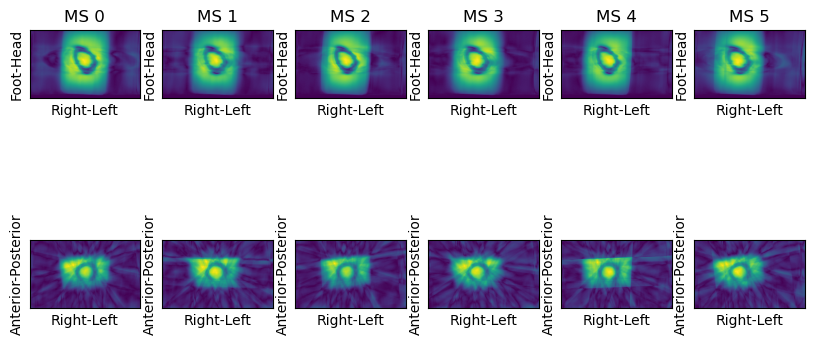

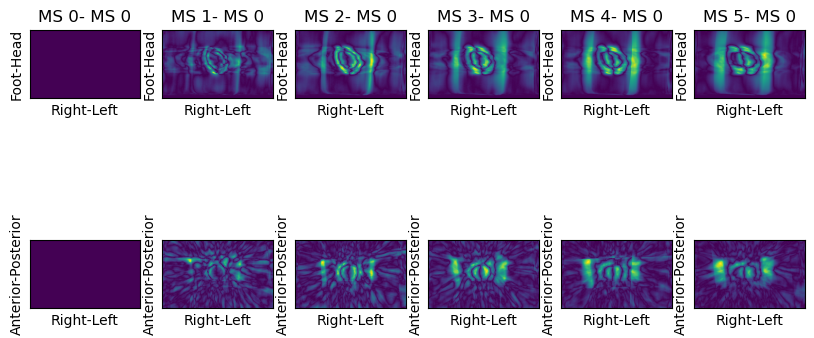

In [ ]:
# Prepare results
#%matplotlib inline
im_fista_ms_arr = []
im_fista_diff_arr = []
for ind in range(Nms):
    im_fista_ms_arr.append(im_fista_ms[ind].as_array())
    im_fista_diff_arr.append(np.abs(im_fista_ms[ind].as_array()) - np.abs(im_fista_ms_arr[0]))
    
# Visualise different motion states
plot_rpe_3d_simple(im_fista_ms_arr[:], [64, 64], [ f'MS {ms}' for ms in range(Nms) ])
print('\n')
# Visualise difference to first motion state
plot_rpe_3d_simple(im_fista_diff_arr[:], [64, 64], [f'MS {ms}- MS 0'  for ms in range(Nms) ])

## Estimate Motion Vector fields

In [ ]:
im_fista_ms_abs = []
for ind in range(Nms):
    im_fista_ms_abs.append(im_fista_ms[ind].abs())

In [ ]:
class NiftyResampleWithNormCache(pReg.NiftyResample):

    def __init__(self, *args, **kwargs):
        self._norm = None
        super().__init__(*args, **kwargs)
        
    def norm(self):
        if self._norm is not None:
            return self._norm
        self._norm = self.calculate_norm()
        return self._norm

    def calculate_norm(self):
        return LinearOperator.PowerMethod(self, method='composed_with_adjoint')

In [ ]:
# Motion fransformation object
mf_resampler = [0] * Nms

# Forward transformation (i.e. reference image transformed to current motion state)
im_forward = [0] * Nms

# Backward transformation (i.e. current motion image transformed to reference motion state)
im_backward = [0] * Nms

tms = []

for shift in shifts:
    t_x=shift
    t_y=0
    tm = pReg.AffineTransformation(np.array(\
            [[1, 0, 0, t_x], \
             [0, 1, 0, t_y], \
             [0, 0, 1, 0  ], \
             [0, 0, 0, 1  ]]))
    tms.append(tm)
    
for ind in range(Nms):

    # Create resampler
    # mf_resampler[ind] = pReg.NiftyResample()
    mf_resampler[ind] = NiftyResampleWithNormCache()
    mf_resampler[ind].set_reference_image(im_fista_ms[0])
    mf_resampler[ind].set_floating_image(im_fista_ms[ind])
    mf_resampler[ind].add_transformation(tms[ind])
    mf_resampler[ind].set_padding_value(0)
    mf_resampler[ind].set_interpolation_type_to_linear()

    im_forward[ind] = mf_resampler[ind].forward(im_fista_ms[0])
    im_backward[ind] = mf_resampler[ind].backward(im_fista_ms[ind])

In [ ]:
mf_resampler[0].norm()

0.9999997019767317

## Let's look at the backward transformed images (i.e. the images transformed to the reference motion state).

In [ ]:
# Prepare results
%matplotlib inline
im_backward_arr = []
im_backward_diff_arr = []
for ind in range(Nms):
    im_backward_arr.append(im_backward[ind].as_array())
    im_backward_diff_arr.append(np.abs(im_backward[ind].as_array()) - np.abs(im_backward[0].as_array()))
    
# Visualise different motion states transformed to reference motion state
plot_rpe_3d_simple(im_backward_arr, [64, 64], [ f'MS {ms}' for ms in range(Nms) ])

# Visualise difference to first motion state
plot_rpe_3d_simple(im_backward_diff_arr, [64, 64], [f'MS {ms}- MS 0'  for ms in range(Nms) ])


In [ ]:
n1 = mf_resampler[0].norm()
print (n1)

In [ ]:
n2 = E_ms[0].norm()

In [ ]:
C = [CompositionOperator(am, res) for am, res in zip(*(E_ms, mf_resampler))]
A = BlockOperator(*C)


In [ ]:
n3 = C[0].norm()

In [ ]:
print (f"C norm: {n3}, E_ms norm: {n2}, mf_resampler norm: {n1}, prod: {n1 * n2}")

## Modifications to CIL/SIRF (check comments to see whether cell(s) can be removed)

In [ ]:
from pReg import NiftyResampler 
from cil.optimisation.operators import LinearOperator


In [ ]:
# this cell is to be removed if using newer CIL version that implements 1470 (leave default, symmetric=False)

# Overriding PowerMethod to ensure no bug
class MyLinearOperator(LinearOperator):
    
    def PowerMethod(operator, max_iteration=10, initial=None, tolerance = 1e-5,  return_all=False):

        symmetric = False
        try:
            if operator.domain_geometry()==operator.range_geometry():
                symmetric = True
        except AssertionError:
            pass

        if initial is None:
            x0 = operator.domain_geometry().allocate('random')
        else:
            x0 = initial.copy()

        y_tmp = operator.range_geometry().allocate()
  
        # Normalize first eigenvector
        x0_norm = x0.norm()
        x0 /= x0_norm
        
        # initial guess for dominant eigenvalue
        eig_old = 1.
        eig_list = []
        diff = np.finfo('d').max
        
        i=0
        while (i < max_iteration and diff > tolerance):
            i+=1
            operator.direct(x0, out = y_tmp)            
            operator.adjoint(y_tmp,out=x0)
            
            # Get eigenvalue using Rayleigh quotient: denominator=1, due to normalization
            x0_norm = x0.norm()      
            x0 /= x0_norm

            eig_new =  np.abs(x0_norm)
            if not symmetric:
                eig_new = np.sqrt(eig_new)

            eig_list.append(eig_new)
            eig_old = eig_new      
        
        if return_all:
            return eig_new, i, x0, eig_list
        else:
            return eig_new
        
    def calculate_norm(self):
        
        r""" Returns the norm of the LinearOperator calculated by the PowerMethod with default values.
                """
        return MyLinearOperator.PowerMethod(self)            


In [ ]:
# this cell is to be removed if using newer SIRF version that implements 1182
from packaging import version as pversion
if pversion.parse(sirf.__version__) < pversion.parse('3.5.0'): 
    def NiftyResampler_norm(x):
        out = LinearOperator.PowerMethod(x)
        return out

    setattr(NiftyResampler, 'norm', NiftyResampler_norm)

In [ ]:
# this cell is to be removed if using newer CIL version that implements 1472

if pversion.parse(cil.version.version) < pversion.parse('23.1.0'):
    def CompositionOperator_norm(comp_operator):
        out = 1.
        for factor in comp_operator.operators:
            out = out * factor.norm()
        return out

    setattr(CompositionOperator, 'norm', CompositionOperator_norm)

In [ ]:
# this cell is to be removed if using newer CIL version that implements 1479


import types   # import needed for later
if pversion.parse(cil.version.version) < pversion.parse('23.1.0'):
    # Overriding proximal, to remove call to function "check_input"
    def new_proximal(self, x, tau, out=None):
        arr = x.as_array()
        if np.iscomplexobj(arr):
            # do real and imag part indep
            in_arr = np.asarray(arr.real, dtype=np.float32, order='C')
            res, info = self.proximal_numpy(in_arr, tau)
            arr.real = res[:]
            in_arr = np.asarray(arr.imag, dtype=np.float32, order='C')
            res, info = self.proximal_numpy(in_arr, tau)
            arr.imag = res[:]
            self.info = info
            if out is not None:
                out.fill(arr)
            else:
                out = x.copy()
                out.fill(arr)
                return out
        else:
            arr = np.asarray(x.as_array(), dtype=np.float32, order='C')
            res, info = self.proximal_numpy(arr, tau)
            self.info = info
            if out is not None:
                out.fill(res)
            else:
                out = x.copy()
                out.fill(res)
                return out

## MCIR with PDHG

In [ ]:
from datetime import datetime

In [ ]:
C = [CompositionOperator(am, res) for am, res in zip(*(E_ms, mf_resampler))]
A = BlockOperator(*C)

acq_ms_block = BlockDataContainer(*acq_ms)
x_init = A.adjoint(acq_ms_block)
x_init.fill(0.0)

F_all_subs = []
for i in acq_ms:
    F_all_subs.append(omega*L2NormSquared(b=i))
    
F = BlockFunction(*F_all_subs)

In [ ]:
G = alpha * FGP_TV(device='cpu', nonnegativity=False)

if pversion.parse(cil.version.version) < pversion.parse('23.1.0'):
    # this line is to be removed if using newer CIL version that implements 1479
    G.proximal = types.MethodType(new_proximal, G)
    print("proximal updated")

nn = G.proximal(im_fista_ms[0], tau=1.0)
plot_rpe_3d_simple([nn.as_array()], [64, 64], ['Proximal'])


In [ ]:
aa = A[0]
aa.norm()

In [ ]:


pdhg_2 = PDHG(
            f=F, g=G, operator=A,
            max_iteration=n_epochs,
            update_objective_interval=10)


In [ ]:
sc = functools.partial(saveCallback, pdhg_2, f"PDHG_TV_{Nms:02d}ms", os.path.join(data_path, recons, f'MS_{Nms}'))
    
start = datetime.now()
pdhg_2.run(10, verbose=2, callback=sc)

pdhg_2.update_objective_interval = 5
pdhg_2.run(5, verbose=2, callback=sc)

pdhg_2.update_objective_interval = 10
pdhg_2.run(verbose=2, callback=sc)
end = datetime.now()

pdhg_2_time = end-start

In [ ]:
im = pdhg_2.get_output().as_array()

%matplotlib inline
plot_rpe_3d([im],
            [59, 64],
            ['PDHG, 4ms'],
            [3*10**(-5)],
            'PDHG, 4ms.png')

## MCIR with SPDHG

In [ ]:
# reuse the same TV instance
# G = alpha * FGP_TV(device='cpu', nonnegativity=False)
# G.proximal = types.MethodType(new_proximal, G)

start = datetime.now()
spdhg_2 = SPDHG(
            f = F, g = G, operator = A, 
            max_iteration = n_epochs*Nms, 
            update_objective_interval = 10*Nms)
  

In [ ]:
sc = functools.partial(saveCallback, pdhg_2, f"SPDHG_TV_{Nms:02d}ms", os.path.join(data_path, recons, f'MS_{Nms}'))
    
start = datetime.now()
spdhg_2.run(10 * Nms, verbose=2, callback=sc)

spdhg_2.update_objective_interval = 5 * Nms
spdhg_2.run(5 * Nms, verbose=2, callback=sc)

spdhg_2.update_objective_interval = 10 * Nms
spdhg_2.run(verbose=2, callback=sc)

end = datetime.now()

spdhg_2_time = end-start

In [ ]:
im = spdhg_2.get_output().as_array()

%matplotlib inline
plot_rpe_3d([im],
            [59, 64],
            [f'SPDHG, {Nms}ms'],
            [3*10**(-5)],
            f'SPDHG, {Nms}ms.png')

In [ ]:
pdhg_2_time.seconds/3600

In [ ]:
spdhg_2_time.seconds/3600

In [ ]:
np.save(os.path.join(data_path, recons, f'MS_{Nms}', 'PDHG_objective.npy'), np.asarray(pdhg_2.objective))

In [ ]:
np.save(os.path.join(data_path, recons, f'MS_{Nms}', 'SPDHG_objective.npy'), np.asarray(spdhg_2.objective))

In [ ]:
# plot PDHG
imgs = []
its = []
import glob
file_pattern = r'PDHG_TV_04ms_it_{:03d}.h5'
for it in range(1,10+1):
    _fname = os.path.join(data_path, recons, file_pattern.format(10*it) )
    imgs.append( pMR.ImageData(file=_fname).as_array() )
    its.append( 'it {}'.format(10 * it) )



## Convergence

In [ ]:
pdhg_2_objective = pdhg_2.objective
spdhg_2_objective = spdhg_2.objective

# save the calculated objective

x_axis_values = np.arange(0,110,10)

plt.plot(x_axis_values, pdhg_2_objective, label='PDHG') 
plt.plot(x_axis_values, spdhg_2_objective, label='SPDHG') 

plt.title('Convergence')
plt.xlabel('epochs')
plt.ylabel('objective')
plt.yscale("log")
plt.legend()
plt.show()

## Error measures

In [ ]:
from skimage.metrics import structural_similarity
from skimage.metrics import mean_squared_error
import math

# Can use either of these two as ground truth
ground_truth_with_TV = np.load(os.path.join(data_path, 'ground_truth_with_TV.npy'))
ground_truth_no_TV = np.load(os.path.join(data_path, 'ground_truth_no_TV.npy'))


def rmse(input_im, ground_truth):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    mse = mean_squared_error(np.abs(input_im), np.abs(ground_truth))
    return math.sqrt(mse)

def nrmse(input_im, ground_truth):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    mse = mean_squared_error(np.abs(input_im), np.abs(ground_truth))
    return math.sqrt(mse) / np.max(np.abs(ground_truth))

def ssim(input_im, ground_truth):
    if np.shape(input_im)!=np.shape(ground_truth):
        raise ValueError('imgs have diff shape')
    res_ssim = structural_similarity(np.abs(input_im), np.abs(ground_truth))
    return res_ssim

In [ ]:
res_pdhg = {'rmse': [], 'nrmse': [], 'ssim': []}

file_pattern = r'PDHG_TV_04ms_it_{:03d}.h5'
for it in range(1,10+1):
    _fname = os.path.join(data_path, recons, file_pattern.format(10*it) )
    res_pdhg['rmse'].append( rmse( pMR.ImageData(file=_fname).as_array(), ground_truth_with_TV) )
    res_pdhg['nrmse'].append( nrmse( pMR.ImageData(file=_fname).as_array(), ground_truth_with_TV) )
    res_pdhg['ssim'].append( ssim( pMR.ImageData(file=_fname).as_array(), ground_truth_with_TV) )

res_spdhg = {'rmse': [], 'nrmse': [], 'ssim': []}
file_pattern = r'SPDHG_TV_04ms_it_{:03d}.h5'
for it in range(1,10+1):
    _fname = os.path.join(data_path, recons, file_pattern.format(10*it*Nms) )
    res_spdhg['rmse'].append( rmse( pMR.ImageData(file=_fname).as_array(), ground_truth_with_TV) )
    res_spdhg['nrmse'].append( nrmse( pMR.ImageData(file=_fname).as_array(), ground_truth_with_TV) )
    res_spdhg['ssim'].append( ssim( pMR.ImageData(file=_fname).as_array(), ground_truth_with_TV) )
    

In [ ]:
epochs = [it * 10 for it in range(1,11)]
plt.plot(epochs, res_pdhg['rmse'], label='PDHG' )
plt.plot(epochs, res_spdhg['rmse'], label='SPDHG' )
plt.legend()
plt.title('RMSE')
plt.xlabel('epoch')
plt.show()

In [ ]:
plt.plot(epochs, res_pdhg['nrmse'], label='PDHG' )
plt.plot(epochs, res_spdhg['nrmse'], label='SPDHG' )
plt.legend()
plt.title('NRMSE')
plt.xlabel('epoch')
plt.show()

In [ ]:
plt.plot(epochs, res_pdhg['ssim'], label='PDHG' )
plt.plot(epochs, res_spdhg['ssim'], label='SPDHG' )
plt.legend()
plt.title('SSIM')
plt.xlabel('epoch')
plt.show()

# RMSE

In [ ]:
im = pdhg_2.get_output().as_array()
print(rmse(im, ground_truth_with_TV))
#print(rmse(im[40:165, 25:105, :, ], ground_truth_with_TV[40:165, 25:105, :, ]))

In [ ]:
im = spdhg_2.get_output().as_array()
print(rmse(im, ground_truth_with_TV))
#print(rmse(im[40:165, 25:105, :, ], ground_truth_with_TV[40:165, 25:105, :, ]))

# SSIM

In [ ]:
im = pdhg_2.get_output().as_array()
print(ssim(im, ground_truth_with_TV))
#print(ssim(im[40:165, 25:105, :, ], ground_truth_with_TV[40:165, 25:105, :, ]))

In [ ]:
im = spdhg_2.get_output().as_array()
print(ssim(im, ground_truth_with_TV))
#print(ssim(im[40:165, 25:105, :, ], ground_truth_with_TV[40:165, 25:105, :, ]))

# NRMSE

In [ ]:
im = pdhg_2.get_output().as_array()
print(nrmse(im, ground_truth_with_TV))
#print(nrmse(im[40:165, 25:105, :, ], ground_truth_with_TV[40:165, 25:105, :, ]))

In [ ]:
im = spdhg_2.get_output().as_array()
print(nrmse(im, ground_truth_with_TV))
#print(nrmse(im[40:165, 25:105, :, ], ground_truth_with_TV[40:165, 25:105, :, ]))

Speed tests

In [ ]:
ms = 1
xxx = E_ms[ms].domain_geometry().allocate(0)
yyy = E_ms[ms].range_geometry().allocate(0)
%%timeit
E_ms[ms].adjoint(acq_ms[ms], out=xxx)
%%timeit
E_ms[ms].direct(xxx, out=yyy)
xxx2 = xxx * 0
ms = 1
%%timeit
mf_resampler[ms].direct(xxx, out=xxx2)

%%timeit
mf_resampler[ms].adjoint(xxx, out=xxx2)
%%timeit
C[ms].direct(xxx, out=yyy)
%%timeit
C[ms].adjoint(yyy, out=xxx)
%%timeit
A.adjoint(acq_ms_block, out=x_init)
yy = acq_ms_block * 0
%%timeit
A.direct(x_init, out=yy)